1. Importing Necessary Libraries

In [1]:
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd, numpy as np

2. Matplotlib Auto-Save Hook for Notebook Visualizations

In [2]:
# Monkey-patch matplotlib.pyplot.show() so every figure is automatically
# saved to PNG, and (optionally) appended to a single PDF report.
# Useful for evaluation notebooks where every plt.show() should produce an artifact on disk.
# 1) Run this cell at the TOP of your notebook.
# 2) Produce plots as usual (plt.figure(), plt.plot(...), plt.show()).
# 3) Every call to plt.show() will auto-save the current figure to  OUT_DIR / f"{FILE_PREFIX}_{NN}.png" and also to the PDF (if enabled).  
# 4) Run finalize_autosave() ONCE at the end to close the PDF and print a summary.

# Output configuration
OUT_DIR = Path("../../eval_viz/ANN_CNN_RNN_Clean_Adversarial")         # Folder where images/PDF will be stored
OUT_DIR.mkdir(parents=True, exist_ok=True)
FILE_PREFIX = "eval"                 # Prefix for sequential PNG filenames
MAKE_PDF = True                      # True => also build a single PDF report

# Internal state (kept minimal and explicit) 
__fig_counter = {'i': 0}    # simple mutable counter (dict to avoid 'nonlocal')
__orig_show = plt.show      # keep original plt.show reference
__pdf = {'obj': PdfPages(OUT_DIR / f"evaluation_visual_report_{datetime.now().strftime('%Y%m%d-%H%M%S')}.pdf")} if MAKE_PDF else {'obj': None}

def _save_current_fig():
    """Save the most recent matplotlib figure to PNG and optionally to the PDF.

    Notes:
        - Uses the last figure number from plt.get_fignums().
        - PNG filenames are sequential: {FILE_PREFIX}_01.png, _02.png, ...
        - PDF appending is enabled only when MAKE_PDF=True.
    """
    fignums = plt.get_fignums()
    if not fignums:
        return
    num = fignums[-1]        # last created/active figure         
    fig = plt.figure(num)  

    __fig_counter['i'] += 1
    fname = f"{FILE_PREFIX}_{__fig_counter['i']:02d}.png"
    fig.savefig(OUT_DIR / fname, dpi=150, bbox_inches="tight")

    if __pdf['obj'] is not None:
        __pdf['obj'].savefig(fig)

def _show_and_save(*args, **kwargs):
    """Replacement for plt.show() that saves the figure before showing it.

    Rationale:
        Saving BEFORE showing ensures we capture the final state even if
        backends clear or alter figures after display.
    """
    _save_current_fig()
    return __orig_show(*args, **kwargs)

# Enable auto-save by monkey-patching plt.show 
plt.show = _show_and_save

def finalize_autosave():
    """Close the PDF (if any) and print a short summary.

    Call this ONCE at the end of the notebook to flush/close the PDF file.
    """
    if __pdf['obj'] is not None:
        try:
            __pdf['obj'].close()
            print("PDF saved.")
        except Exception as e:
            print("⚠ Error while closing PDF:", e)
    print(f"[AutoSave] Saved {__fig_counter['i']} PNG(s)  to:", OUT_DIR)

print(f"[AutoSave] Enabled. PNGs => {OUT_DIR}, PDF => {MAKE_PDF}")


[AutoSave] Enabled. PNGs => ..\..\eval_viz\ANN_CNN_RNN_Clean_Adversarial, PDF => True


3. Resolve Evaluation Summary Path & Define Class Names

In [3]:
# Minimal helper that sets CLASS_NAMES and locates `evaluation_summary.xlsx`
# 1) ./evaluation_summary.xlsx if it exists
# 2) the most recently modified file named `evaluation_summary.xlsx` in '.'
# 3) a placeholder absolute path (fallback)

# Project class names (order matters if you index by class id) 
CLASS_NAMES = ['go', 'warning', 'stop']

# Try to resolve the Excel summary in the current directory 
DEFAULT_SUMMARY = Path('../../eval_tables/evaluation_summary.xlsx')
if DEFAULT_SUMMARY.exists():
    SUMMARY_PATH = DEFAULT_SUMMARY
else:
    # Look for any file literally named 'evaluation_summary.xlsx' in '.'
    candidates = list(Path('.').glob('../../eval_tables/evaluation_summary.xlsx'))
    # Pick the most recently modified, or fall back to a placeholder path
    SUMMARY_PATH = max(candidates, key=lambda p: p.stat().st_mtime) if candidates else Path("../../eval_tables/evaluation_summary.xlsx")

# Short status output for sanity checks 
print('SUMMARY_PATH:', SUMMARY_PATH)
print('CLASS_NAMES:', CLASS_NAMES)

SUMMARY_PATH: ..\..\eval_tables\evaluation_summary.xlsx
CLASS_NAMES: ['go', 'warning', 'stop']


4. Read Evaluation Summary Sheets (Excel)

In [4]:
# Utility to read the core sheets from `evaluation_summary.xlsx`:
# - "Summary"      (required)
# - "TPFPFNTN"     (optional)
# - "Confusions"   (optional)
# Uses openpyxl when available and falls back gracefully if not.

def read_summary_sheets(xlsx_path: Path):
    """Read the main evaluation sheets from the summary Excel file.

    Attempts to use the 'openpyxl' engine first for compatibility, and falls
    back to pandas' default engine if 'openpyxl' is not installed.

    Args:
        xlsx_path: Path to the Excel file (e.g., Path("evaluation_summary.xlsx")).

    Returns:
        A tuple of:
            - df_summary: Required dataframe for the "Summary" sheet.
            - df_tpfp: Optional dataframe for the "TPFPFNTN" sheet (or None if missing).
            - df_cm: Optional dataframe for the "Confusions" sheet (or None if missing).
    """
    # Summary (required) 
    try:
        df_summary = pd.read_excel(xlsx_path, sheet_name='Summary', engine='openpyxl')
    except Exception:
        df_summary = pd.read_excel(xlsx_path, sheet_name='Summary')

    # TPFPFNTN (optional)
    try:
        df_tpfp = pd.read_excel(xlsx_path, sheet_name='TPFPFNTN', engine='openpyxl')
    except Exception:
        try:
            df_tpfp = pd.read_excel(xlsx_path, sheet_name='TPFPFNTN')
        except Exception:
            df_tpfp = None

    # Confusions (optional) 
    try:
        df_cm = pd.read_excel(xlsx_path, sheet_name='Confusions', engine='openpyxl')
    except Exception:
        try:
            df_cm = pd.read_excel(xlsx_path, sheet_name='Confusions')
        except Exception:
            df_cm = None

    return df_summary, df_tpfp, df_cm

# Execute & quick peek (notebook-friendly)
df_summary, df_tpfp, df_cm = read_summary_sheets(SUMMARY_PATH)

print('Summary head:'); 
display(df_summary.head())

print("TPFPFNTN head:" if df_tpfp is not None else "No 'TPFPFNTN' sheet found.")
display(df_tpfp.head()) if df_tpfp is not None else None

print('Confusions head:' if df_cm is not None else "No 'Confusions' sheet found (optional).")
display(df_cm.head()) if df_cm is not None else None

Summary head:


,model,dataset,n_samples,acc,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,auroc_macro_ovr,auprc_macro_ovr,tpr_at_fpr_0.01_macro_ovr,ece_top1,ms_per_sample,color_space,bind_by_name
0,ANN,clean_test,11599,0.999138,0.996843,0.996008,0.996425,0.999137,0.999138,0.999137,0.999879,0.998696,0.998060,0.423410,0.204070,BGR,True
1,ANN,Annotations_ANN_fgsm,11599,0.503837,0.532177,0.445716,0.464089,0.507895,0.503837,0.489676,0.586232,0.469829,0.124132,0.063024,0.258642,BGR,True
2,ANN,Annotations_ANN_pgd,11599,0.652125,0.688274,0.606822,0.636978,0.656424,0.652125,0.650821,0.841498,0.761700,0.407601,0.149483,0.332970,BGR,True
3,ANN,Annotations_CNN_fgsm,11599,0.988965,0.965501,0.977113,0.971182,0.989065,0.988965,0.989002,0.999153,0.993690,0.985572,0.416160,0.289883,BGR,True
4,ANN,Annotations_CNN_pgd,11599,0.997845,0.995932,0.989139,0.992495,0.997843,0.997845,0.997839,0.999734,0.997840,0.997210,0.422418,0.640383,BGR,True


TPFPFNTN head:


,model,dataset,class_id,class_name,TP,FP,FN,TN
0,ANN,clean_test,0,go,5438,4,1,6156
1,ANN,clean_test,1,warning,362,3,4,11230
2,ANN,clean_test,2,stop,5789,3,5,5802
3,ANN,Annotations_ANN_fgsm,0,go,3714,3764,1725,2396
4,ANN,Annotations_ANN_fgsm,1,warning,112,79,254,11154


Confusions head:


,model,dataset,true,pred,count
0,ANN,clean_test,go,go,5438
1,ANN,clean_test,warning,go,1
2,ANN,clean_test,stop,go,3
3,ANN,clean_test,go,warning,1
4,ANN,clean_test,warning,warning,362


5. Core Pivots for Key Metrics (Accuracy, Macro F1, ECE)

In [5]:
# Minimal pivot + styled display for Model × Dataset summaries.

pv_acc = df_summary.pivot(index='model', columns='dataset', values='acc').sort_index()
display(pv_acc.style.format('{:.4f}').set_caption('Accuracy by Model × Dataset'))

pv_f1 = df_summary.pivot(index='model', columns='dataset', values='f1_macro').sort_index()
display(pv_f1.style.format('{:.4f}').set_caption('Macro F1 by Model × Dataset'))

pv_ece = df_summary.pivot(index='model', columns='dataset', values='ece_top1').sort_index()
display(pv_ece.style.format('{:.4f}').set_caption('ECE (Top-1) by Model × Dataset'))

dataset,Annotations_ANN_fgsm,Annotations_ANN_pgd,Annotations_CNN_fgsm,Annotations_CNN_pgd,Annotations_RNN_fgsm,Annotations_RNN_pgd,clean_test
model,,,,,,,
ANN,0.5038,0.6521,0.9890,0.9978,0.9223,0.9960,0.9991
CNN,0.6713,0.8771,0.6962,0.5767,0.8909,0.9706,0.9988
RNN,0.8247,0.9586,0.9864,0.9959,0.4928,0.5117,0.9974


dataset,Annotations_ANN_fgsm,Annotations_ANN_pgd,Annotations_CNN_fgsm,Annotations_CNN_pgd,Annotations_RNN_fgsm,Annotations_RNN_pgd,clean_test
model,,,,,,,
ANN,0.4641,0.6370,0.9712,0.9925,0.9304,0.9939,0.9964
CNN,0.6898,0.8440,0.6746,0.4948,0.8507,0.9573,0.9962
RNN,0.8004,0.9549,0.9790,0.9896,0.3689,0.4348,0.9940


dataset,Annotations_ANN_fgsm,Annotations_ANN_pgd,Annotations_CNN_fgsm,Annotations_CNN_pgd,Annotations_RNN_fgsm,Annotations_RNN_pgd,clean_test
model,,,,,,,
ANN,0.0630,0.1495,0.4162,0.4224,0.3535,0.4212,0.4234
CNN,0.1371,0.3201,0.1509,0.1300,0.3390,0.3988,0.4233
RNN,0.2817,0.4043,0.4143,0.4215,0.0547,0.0565,0.4226


6. Grouped Bar Charts by Dataset (Models as Groups)

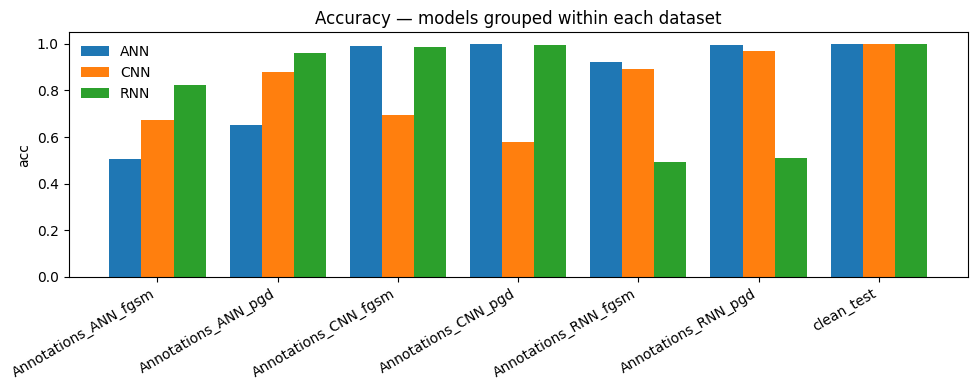

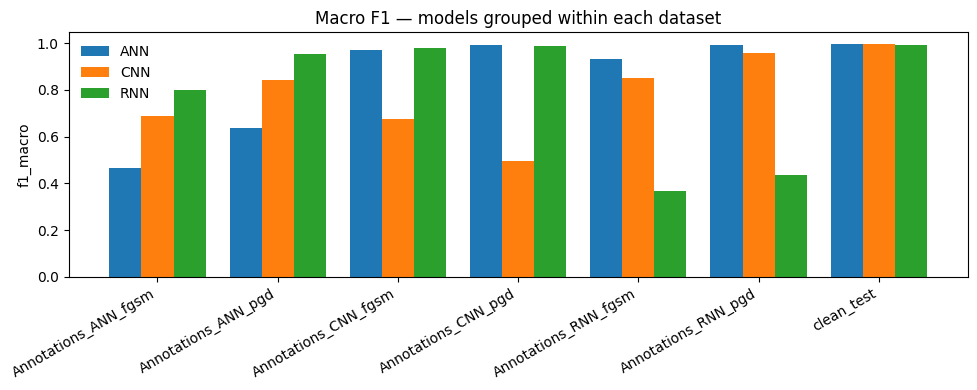

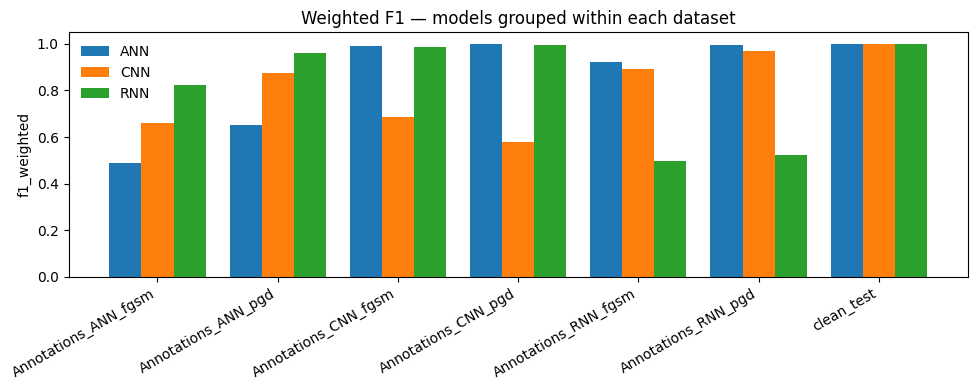

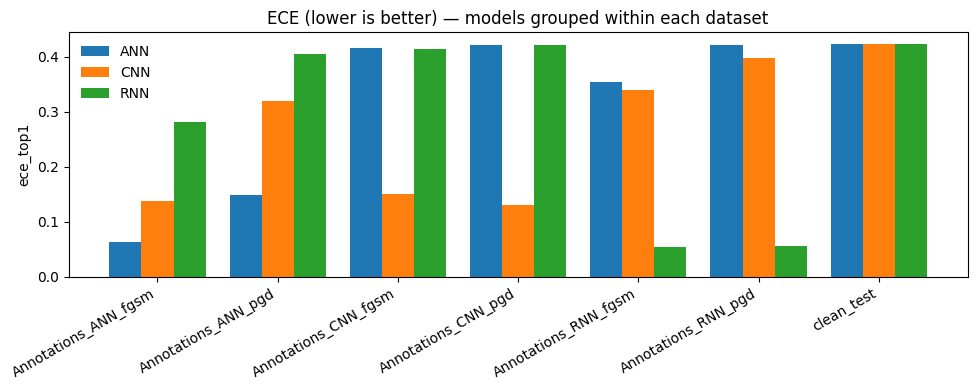

In [6]:
# Minimal helper to plot grouped bars for a given metric across datasets, with models forming the groups per dataset. Structure intentionally unchanged.

def grouped_bars(metric_col: str, title: str):
    """Plot grouped bar charts for `metric_col` across datasets, grouping by model."""
    df = df_summary.copy(); models = sorted(df['model'].unique()); datasets = sorted(df['dataset'].unique())
    width = 0.8 / max(len(models), 1); x = np.arange(len(datasets))
    plt.figure(figsize=(10,4))
    for i, m in enumerate(models):
        sub = df[df['model']==m].set_index('dataset').reindex(datasets)
        vals = sub[metric_col].values
        plt.bar(x + i*width, vals, width, label=m)
    plt.xticks(x + width*(len(models)-1)/2, datasets, rotation=30, ha='right')
    plt.ylabel(metric_col); plt.title(title); plt.legend(frameon=False); plt.tight_layout(); plt.show()
    
grouped_bars('acc', 'Accuracy — models grouped within each dataset')
grouped_bars('f1_macro', 'Macro F1 — models grouped within each dataset')
grouped_bars('f1_weighted', 'Weighted F1 — models grouped within each dataset')
grouped_bars('ece_top1', 'ECE (lower is better) — models grouped within each dataset')

7. Per-Class TP/FP/FN/TN Stacked Bars per (Model × Dataset)

,model,dataset,class_id,class_name,TP,FP,FN,TN
0,ANN,clean_test,0,go,5438,4,1,6156
1,ANN,clean_test,1,warning,362,3,4,11230
2,ANN,clean_test,2,stop,5789,3,5,5802
3,ANN,Annotations_ANN_fgsm,0,go,3714,3764,1725,2396
4,ANN,Annotations_ANN_fgsm,1,warning,112,79,254,11154


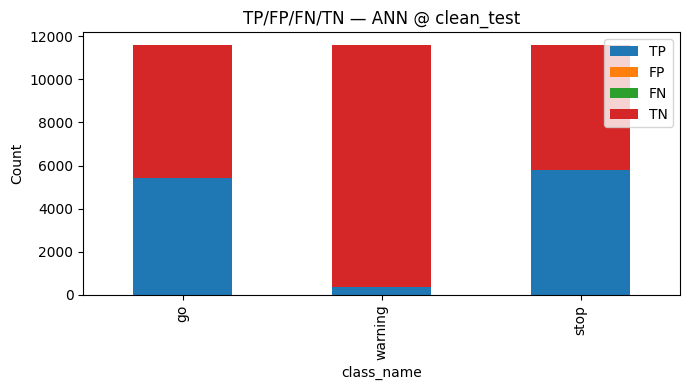

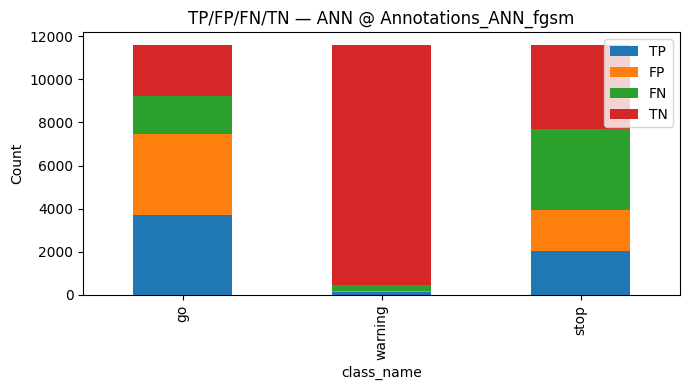

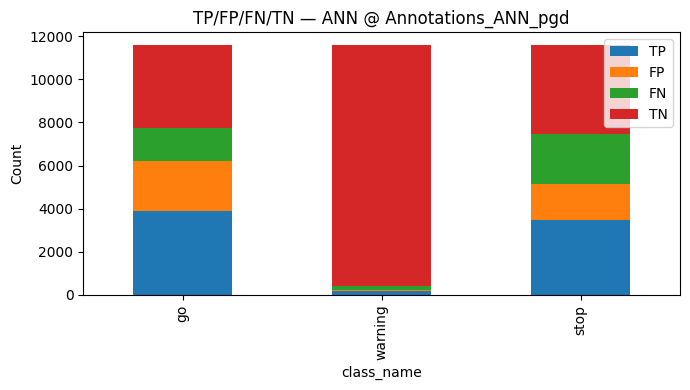

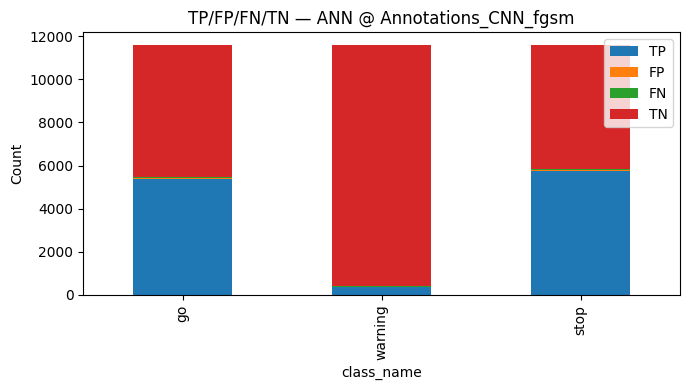

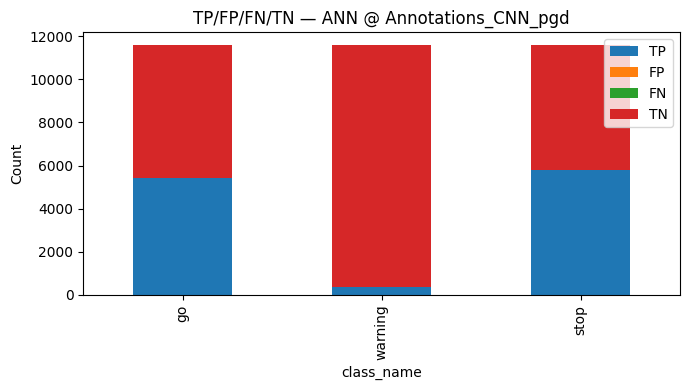

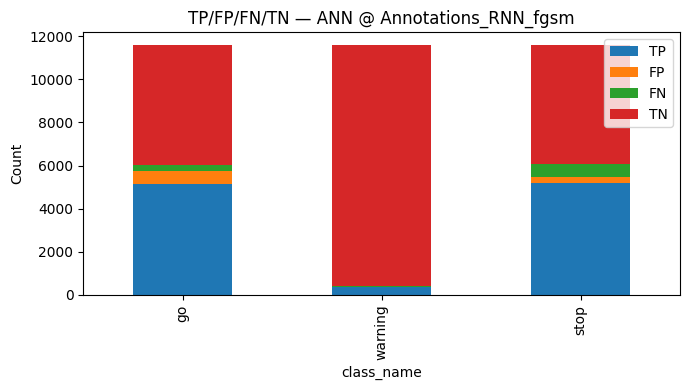

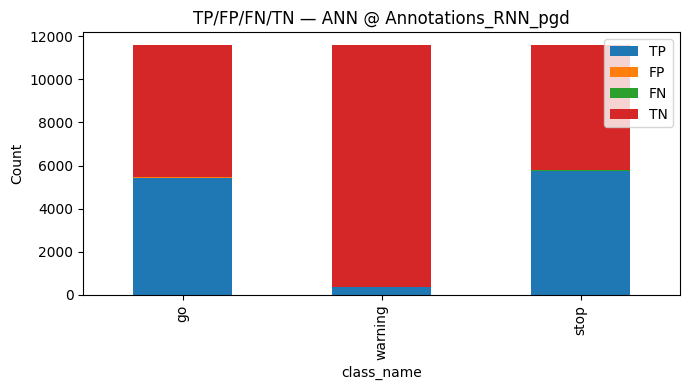

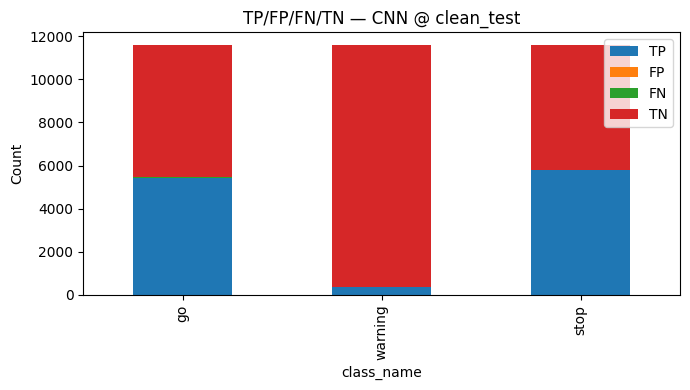

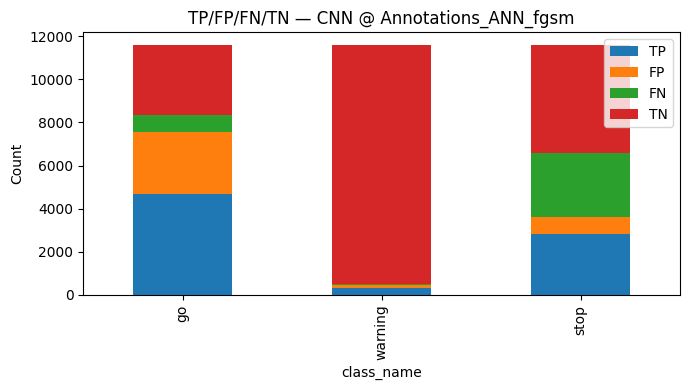

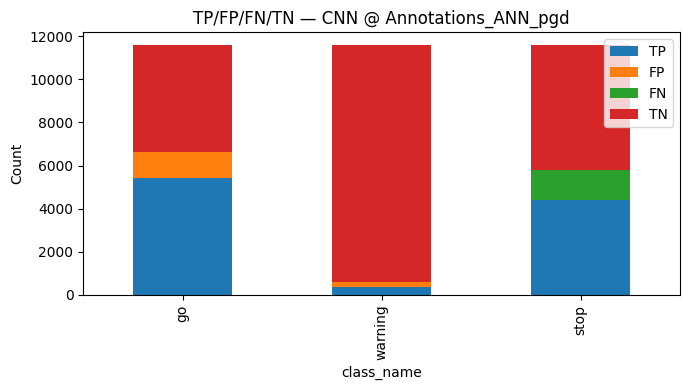

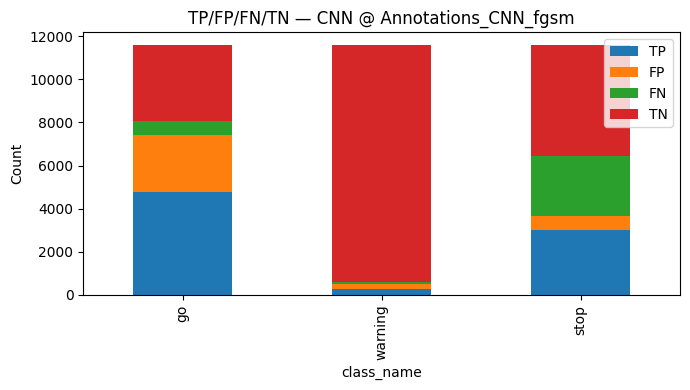

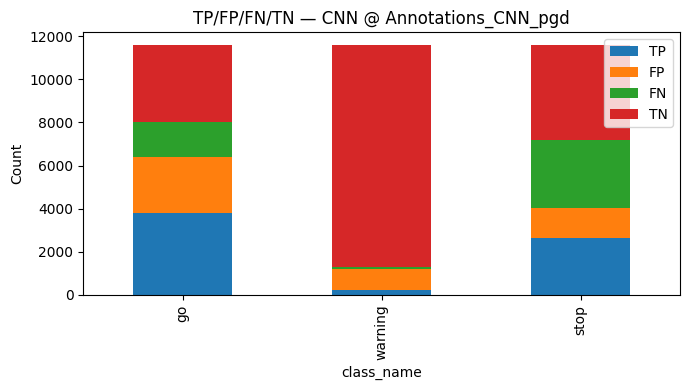

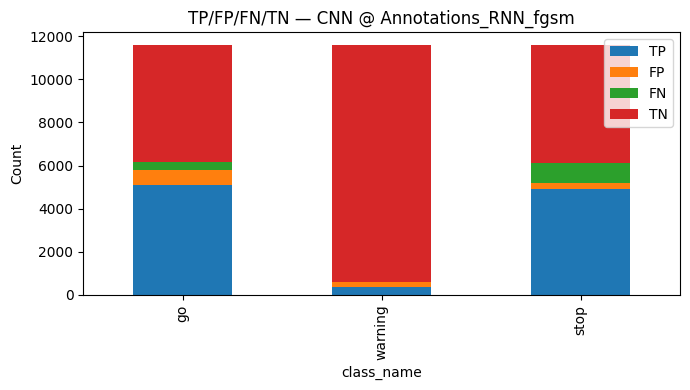

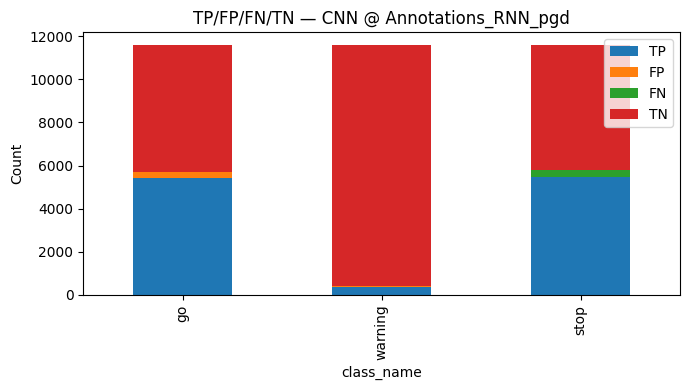

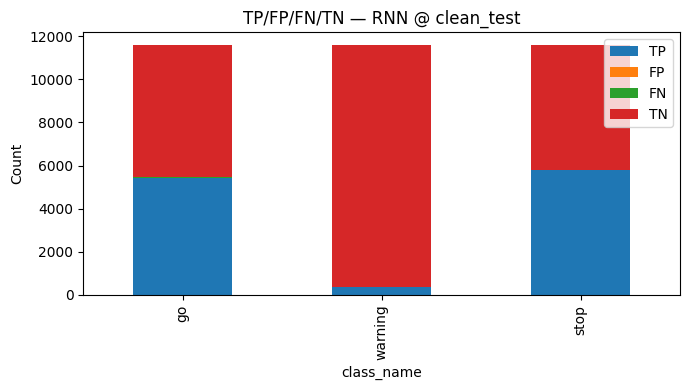

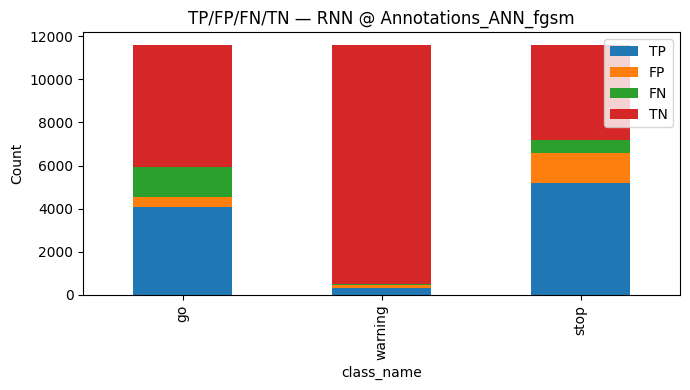

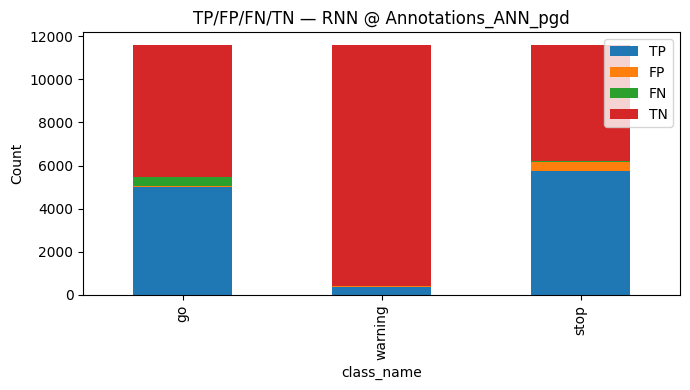

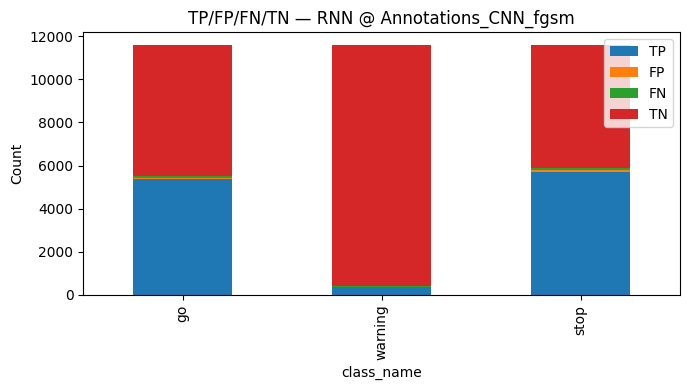

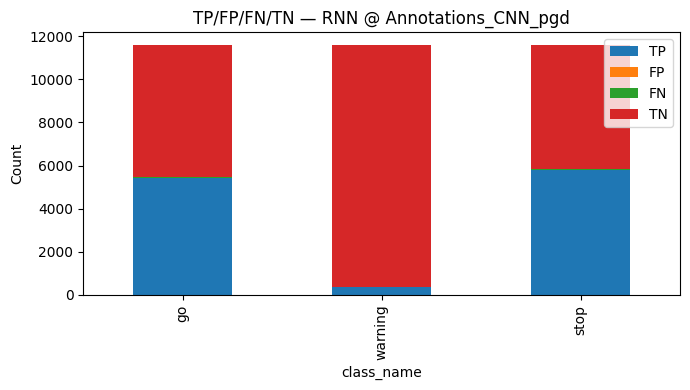

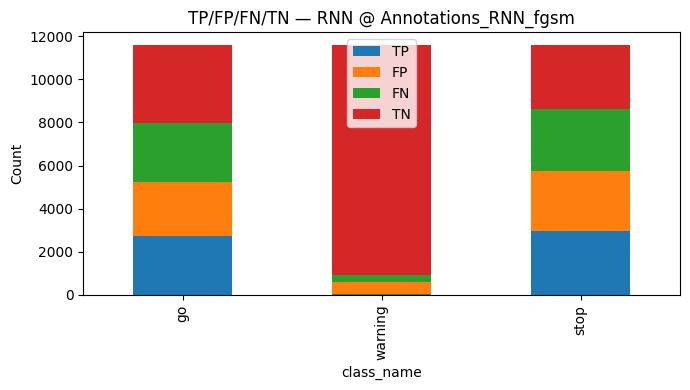

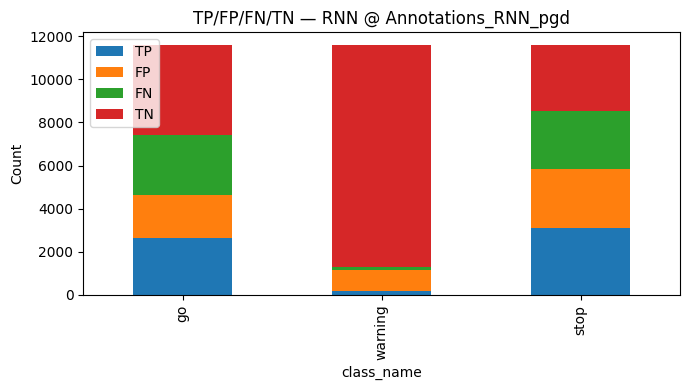

In [7]:
# If the TPFPFNTN sheet exists, show a head preview and then plot stacked bar charts (TP/FP/FN/TN) for every (model, dataset) combo.

if df_tpfp is not None and not df_tpfp.empty:
    display(df_tpfp.head())

    def plot_tpfp_for(model: str, dataset: str):
        """Plot stacked TP/FP/FN/TN counts per class for a given (model, dataset)."""
        sub = df_tpfp[(df_tpfp['model']==model) & (df_tpfp['dataset']==dataset)]
        if sub.empty:
            print(f'No TP/FP/FN/TN for {model} @ {dataset}'); return
        sub = sub.set_index('class_name').reindex(CLASS_NAMES)
        counts = sub[['TP','FP','FN','TN']]
        counts.plot(kind='bar', stacked=True, figsize=(7,4), title=f'TP/FP/FN/TN — {model} @ {dataset}')
        plt.ylabel('Count'); plt.tight_layout(); plt.show()
        
    combos = df_tpfp[['model','dataset']].drop_duplicates().values
    for model, dataset in combos:
        plot_tpfp_for(model, dataset)
else:
    print("No TP/FP/FN/TN sheet available. Re-run notebook 12 and save with TPFPFNTN sheet.")

8. Confusion Matrices per (Model × Dataset)

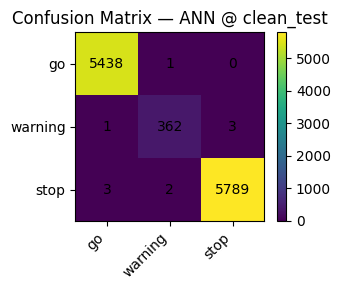

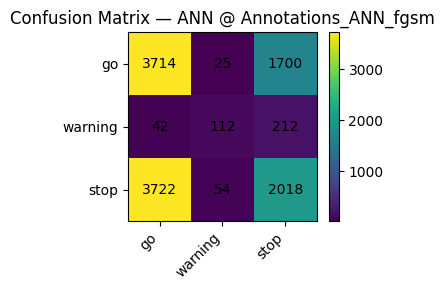

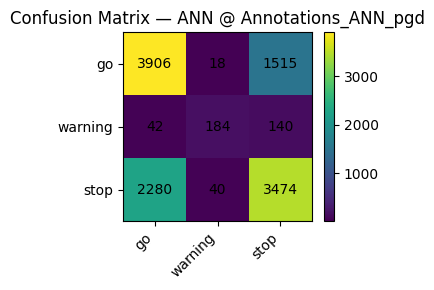

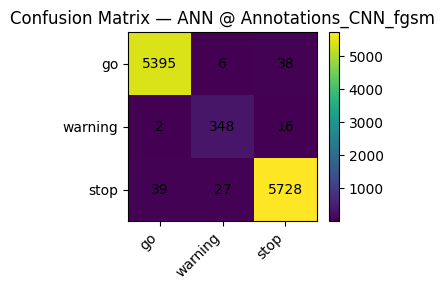

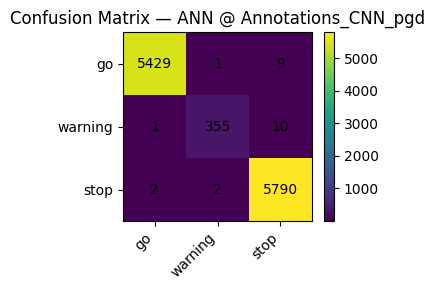

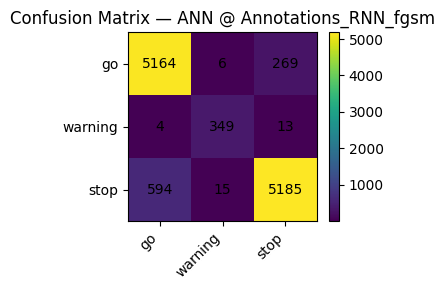

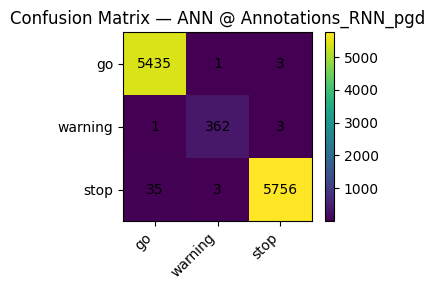

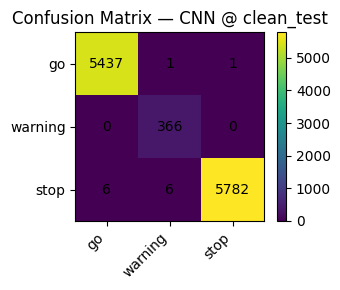

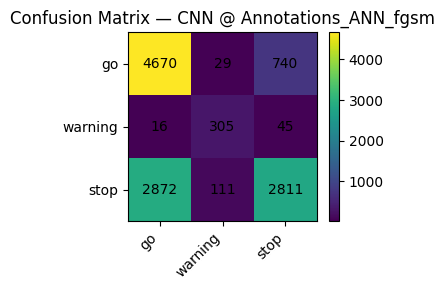

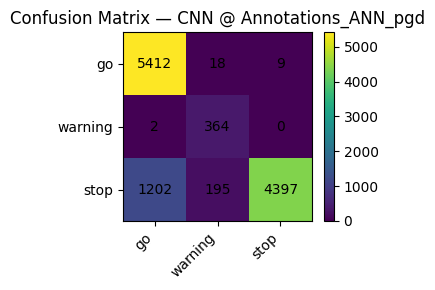

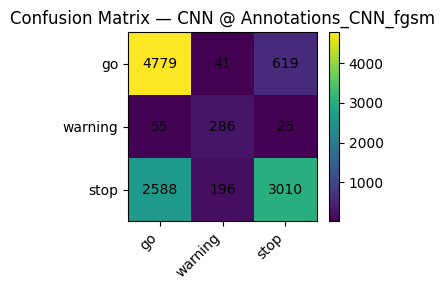

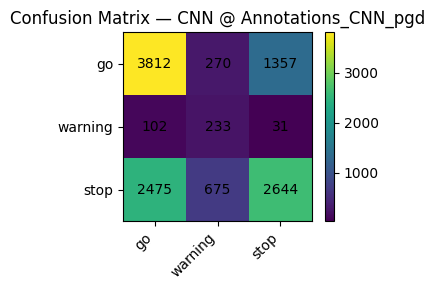

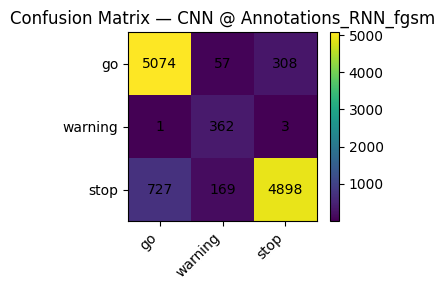

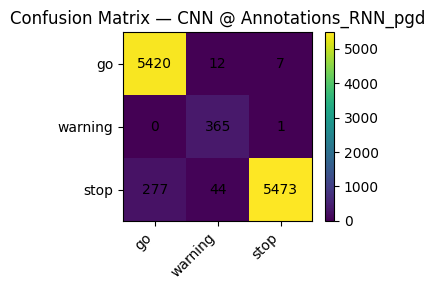

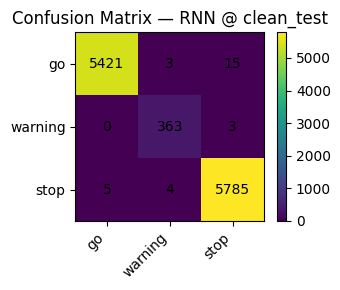

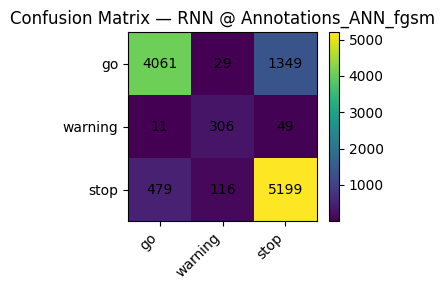

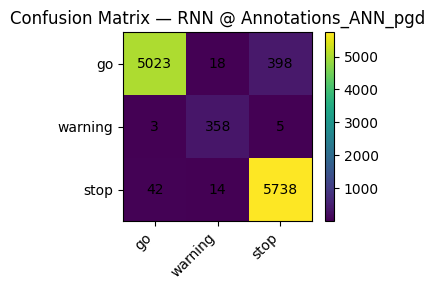

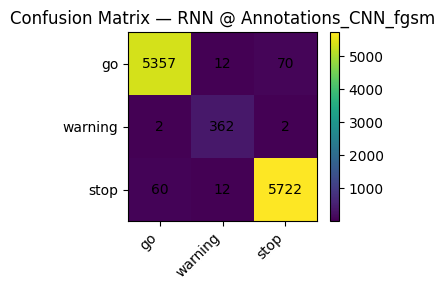

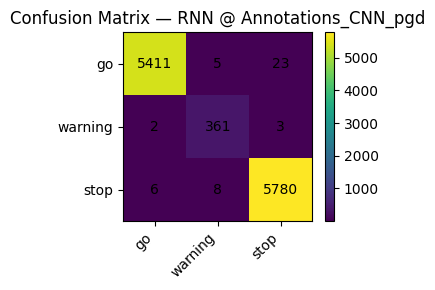

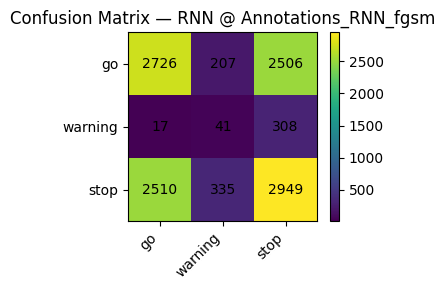

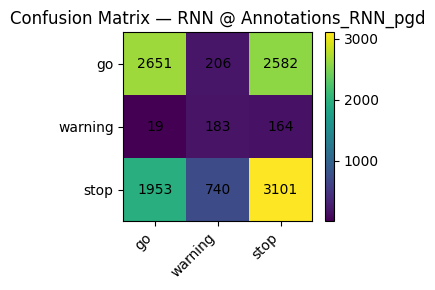

In [8]:
# Render per-combo confusion matrices from the 'Confusions' sheet.

if df_cm is not None and not df_cm.empty:
    combos = df_cm[['model','dataset']].drop_duplicates().values
    for model, dataset in combos:
        sub = df_cm[(df_cm['model']==model) & (df_cm['dataset']==dataset)]
        if sub.empty: continue
        pivot = (sub.pivot(index='true', columns='pred', values='count')
                 .reindex(index=CLASS_NAMES, columns=CLASS_NAMES).fillna(0))
        plt.figure(figsize=(4,3)); plt.title(f'Confusion Matrix — {model} @ {dataset}')
        im = plt.imshow(pivot.values, interpolation='nearest')
        plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45, ha='right')
        plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
        plt.colorbar(im, fraction=0.046, pad=0.04)
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                plt.text(j, i, int(pivot.values[i, j]), ha='center', va='center')
        plt.tight_layout(); plt.show()
else:
    print("No 'Confusions' sheet found. (Optional feature)")

9. Close PDF & Print Autosave Summary

In [9]:
# Gracefully finalize the auto-save PDF and print a short summary.

# END OF NOTEBOOK: close PDF & print summary 
try:
    finalize_autosave()
except NameError:
    print("AutoSave dont run.")

PDF saved.
[AutoSave] Saved 46 PNG(s)  to: ..\..\eval_viz\ANN_CNN_RNN_Clean_Adversarial
